In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
# Load the dataset
file_path = 'Test_data.csv' 
data = pd.read_csv(file_path)


In [3]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00
1,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [5]:
data.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


C:\Users\Chinu\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


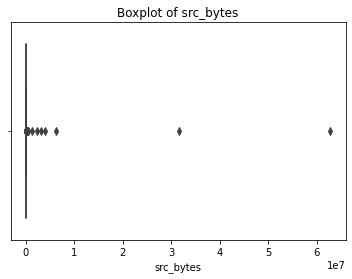

In [6]:
# Boxplot for 'src_bytes'
plt.figure(figsize=(6, 4))
sns.boxplot(data['src_bytes'])
plt.title('Boxplot of src_bytes')
plt.show()

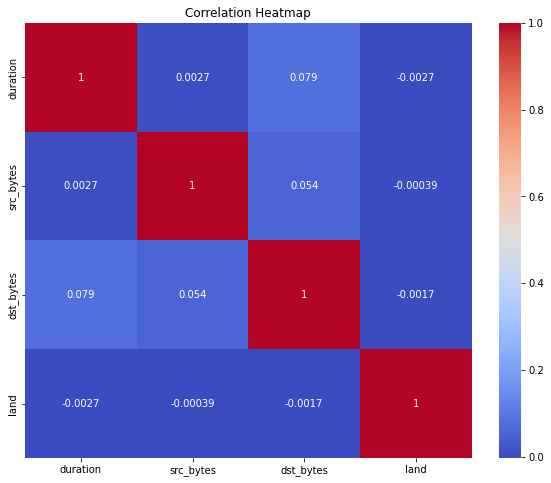

In [7]:
#  subset of features
subset_features = ['duration', 'src_bytes', 'dst_bytes', 'land']  # Change as needed
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data[subset_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

C:\Users\Chinu\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


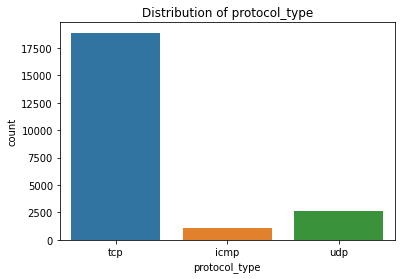

C:\Users\Chinu\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


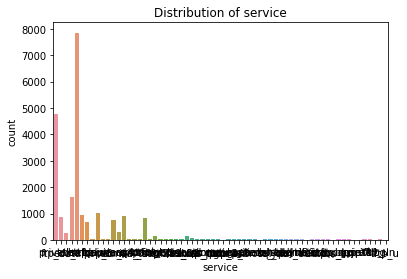

C:\Users\Chinu\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


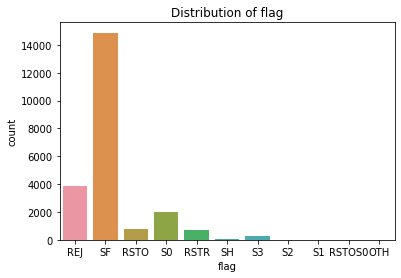

In [8]:
# Countplot for categorical features
for col in ['protocol_type', 'service', 'flag']:
    sns.countplot(data[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [9]:
# Identify categorical and numerical columns
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = list(set(data.columns) - set(categorical_cols) - {'src_bytes'})  # Assuming 'src_bytes' as target

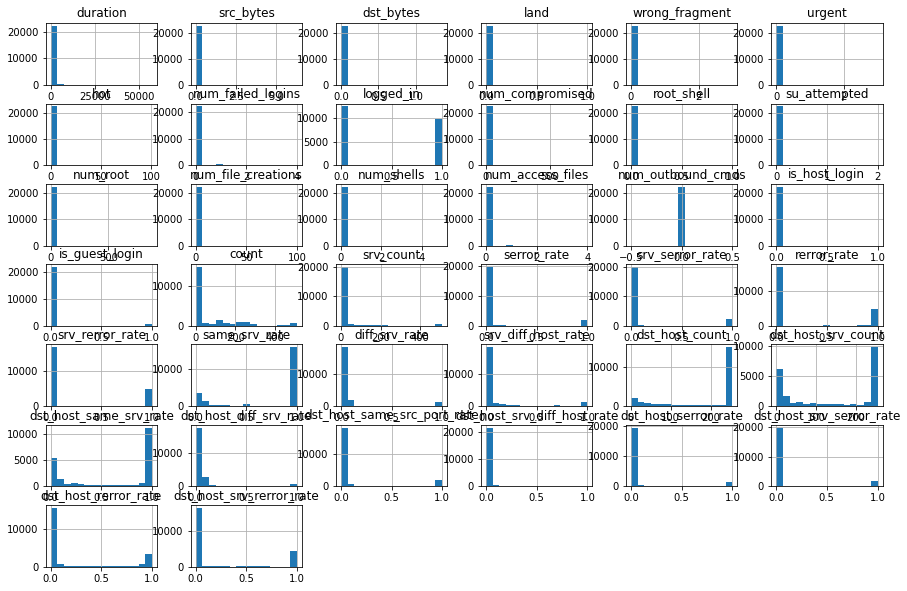

In [10]:
# Histograms for numerical features
data.hist(bins=15, figsize=(15, 10))
plt.show()

C:\Users\Chinu\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


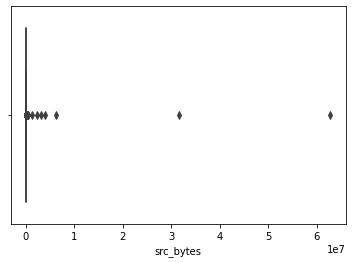

In [11]:
# Boxplot for 'src_bytes'
plt.figure(figsize=(6, 4))
sns.boxplot(data['src_bytes'])
plt.show()

In [12]:
# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [13]:
# Apply preprocessing
X = data.drop('src_bytes', axis=1)
y = data['src_bytes']
X_processed = preprocessor.fit_transform(X)

In [14]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=0)


In [15]:
from sklearn.neural_network import MLPRegressor

# Defining the MLPRegressor model
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=300, random_state=1)

# Training the model
mlp_model.fit(X_train, y_train)

# Scoring the model on the test set
mlp_score = mlp_model.score(X_test, y_test)
print(f"MLPRegressor Test Score: {mlp_score:.4f}")


MLPRegressor Test Score: 0.0391


C:\Users\Chinu\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
from sklearn.metrics import mean_squared_error

# Predictions and Evaluation
y_pred_mlp = mlp_model.predict(X_test)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
print(f"Mean Squared Error (MLPRegressor): {mse_mlp}")

Mean Squared Error (MLPRegressor): 222616103671.3241


In [17]:
# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [19]:
# Predictions and Evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 5.90430574353357e+31


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [21]:
# Scoring the model on the test set
rf_score = rf_model.score(X_test, y_test)
print(f"Random Forest Regressor Test Score: {rf_score:.4f}")

# Predictions and Evaluation
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Squared Error (Random Forest): {mse_rf}")

Random Forest Regressor Test Score: 0.9070
Mean Squared Error (Random Forest): 21538588738.69057


In [22]:
from flask import Flask, request, jsonify
import joblib

In [23]:
# Fit the preprocessor on the data
preprocessor.fit(X)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['dst_host_same_src_port_rate', 'count',
                                  'dst_host_srv_count', 'num_shells',
                                  'rerror_rate', 'land', 'wrong_fragment',
                                  'is_guest_login', 'srv_rerror_rate',
                                  'is_host_login', 'duration',
                                  'num_file_creations', 'hot', 'diff_srv_rate',
                                  'num_compromised', 'dst_host_same_srv_rate',
                                  'num_access_files', 'urgent', 'same_srv_rate',
                                  'dst_host_serror_rate',
                                  'dst_host_srv_rerror_rate', 'root_shell',
                                  'srv_diff_host_rate',
                                  'dst_host_diff_srv_rate',
                                  'dst_host_srv_serror_rate', 'srv_serror_rate',
                                  'num_root', 'dst_host_count', 'su_attempted',
                                  'num_outbound_cmds', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag'])])

In [24]:
# Extract feature names from the preprocessor
def get_feature_names(column_transformer):
    # Get feature names from all transformers
    output_features = []

    for name, pipe, features in column_transformer.transformers_:
        if name != 'remainder':
            if hasattr(pipe, 'get_feature_names'):
                # If a transformer has a 'get_feature_names' method, use it
                feature_names = pipe.get_feature_names(input_features=features)
                output_features.extend(feature_names)
            else:
                # Otherwise, use the feature names directly
                output_features.extend(features)

    return output_features

feature_names = get_feature_names(preprocessor)

# Save the feature names for later use in the Flask app
joblib.dump(feature_names, 'feature_names.pkl')


['feature_names.pkl']

In [25]:
feature_names

['dst_host_same_src_port_rate',
 'count',
 'dst_host_srv_count',
 'num_shells',
 'rerror_rate',
 'land',
 'wrong_fragment',
 'is_guest_login',
 'srv_rerror_rate',
 'is_host_login',
 'duration',
 'num_file_creations',
 'hot',
 'diff_srv_rate',
 'num_compromised',
 'dst_host_same_srv_rate',
 'num_access_files',
 'urgent',
 'same_srv_rate',
 'dst_host_serror_rate',
 'dst_host_srv_rerror_rate',
 'root_shell',
 'srv_diff_host_rate',
 'dst_host_diff_srv_rate',
 'dst_host_srv_serror_rate',
 'srv_serror_rate',
 'num_root',
 'dst_host_count',
 'su_attempted',
 'num_outbound_cmds',
 'dst_host_srv_diff_host_rate',
 'serror_rate',
 'dst_bytes',
 'srv_count',
 'logged_in',
 'num_failed_logins',
 'dst_host_rerror_rate',
 'protocol_type',
 'service',
 'flag']

In [26]:
# Save the preprocessor and the model
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']